## 01. 회귀 평가지표  

회귀 평가지표는 모델이 예측한 숫자와 실제 숫자의 차이를 계산해 회귀 모델의 성능을 수치로 표현한 기준이다.  
회귀 모델은 class가 아니라 연속적인 숫자 값을 예측하므로, 평가지표는 예측값이 실제값과 얼마나 가까운지 확인하는 데 사용한다.  

회귀 평가는 단순히 맞음/틀림으로 판단하지 않는다.  
예측값과 실제값 사이의 차이가 얼마나 큰지, 큰 오차를 얼마나 민감하게 볼 것인지, 평균값만 예측하는 기준보다 얼마나 나은지를 함께 확인한다.  

- `MAE`: 오차의 절댓값을 평균낸 지표임.  
- `MSE`: 오차를 제곱한 뒤 평균낸 지표임.  
- `RMSE`: MSE에 제곱근을 씌워 실제 target과 비슷한 단위로 해석하는 지표임.  
- `R2`: 평균값으로만 예측하는 기준보다 모델이 target 변화를 얼마나 잘 설명하는지 보는 지표임.  

**회귀 모델과 평가의 관계**  

- 회귀 모델: 숫자 값을 예측하는 모델임.  
- 회귀 평가지표: 모델의 숫자 예측값이 실제값과 얼마나 가까운지 판단하는 기준임.  

분류에서는 맞음/틀림을 기준으로 accuracy를 계산할 수 있지만, 회귀에서는 예측값이 실제값과 얼마나 차이 나는지가 중요하다.  
예측값이 100이고 실제값이 102라면 완전히 틀렸다고만 볼 수 없다. 오차가 2 정도라면 충분히 좋은 예측일 수 있다.  

**배우는 이유**  
- 회귀 모델의 예측 오차 크기를 숫자로 판단하기 위해 사용함.  
- 큰 오차가 치명적인 문제인지, 평균적인 오차가 중요한 문제인지 구분하기 위해 사용함.  
- 여러 회귀 모델 중 어떤 모델을 선택할지 근거를 만들기 위해 사용함.  
- 프로젝트 보고서에서 “모델이 좋다”가 아니라 “평균적으로 얼마나 틀리는지”를 설명하기 위해 사용함.  

**어디서 사용하는가?**  
- 집값 예측: 평균적으로 몇 천만 원 정도 틀리는지 확인함.  
- 수요 예측: 재고 부족이나 과잉 재고를 줄이기 위해 오차를 확인함.  
- 매출 예측: 실제 매출과 예측 매출의 차이를 기준으로 모델을 비교함.  
- 의료 수치 예측: 큰 오차가 위험할 수 있어 RMSE를 함께 확인함.  

**핵심 용어**  
- 실제값: 정답 target 값임.  
- 예측값: 모델이 만든 숫자 결과임.  
- 잔차(residual): 실제값 - 예측값임.  
- 오차(error): 실제값과 예측값의 차이를 의미함.  
- 기준 모델: 복잡한 모델을 만들기 전에 최소한 이겨야 하는 단순 예측 기준임.  

**지표를 읽는 기본 방향**  
- MAE, MSE, RMSE는 낮을수록 예측 오차가 작다.  
- R2는 일반적으로 높을수록 평균 예측보다 모델이 target 변화를 더 잘 설명한다.  
- 단, R2만 높다고 좋은 모델이라고 단정하지 않고 MAE/RMSE의 실제 오차 크기를 함께 확인한다.  


## 02. 실습 환경 준비

회귀 평가지표는 직접 계산해 보면 의미가 훨씬 분명해진다.
작은 배열 예제로 지표를 먼저 확인한 뒤, Diabetes 데이터로 실제 모델 평가를 진행한다.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)


## 03. 작은 예제로 residual 이해하기

residual은 실제값에서 예측값을 뺀 값이다.
residual이 양수이면 모델이 실제보다 작게 예측한 것이고, 음수이면 실제보다 크게 예측한 것이다.


In [2]:
y_true = np.array([3.0, 0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.0, 5.0])

# residual: 실제값 - 예측값
# 양수이면 모델이 실제값보다 작게 예측한 것이고, 음수이면 실제값보다 크게 예측한 것이다.
residual = y_true - y_pred

residual_df = pd.DataFrame({
    'actual': y_true,
    'predicted': y_pred,
    'residual_actual_minus_pred': residual,
    'absolute_error': np.abs(residual),
    'squared_error': residual ** 2,
})

display(residual_df)

,actual,predicted,residual_actual_minus_pred,absolute_error,squared_error
0,3.0,2.5,0.5,0.5,0.25
1,0.5,0.0,0.5,0.5,0.25
2,2.0,2.0,0.0,0.0,0.00
3,7.0,5.0,2.0,2.0,4.00


## 04. MAE, MSE, RMSE, R2 직접 계산

- MAE: 오차 절댓값 평균임.
- MSE: 오차 제곱 평균임.
- RMSE: MSE에 제곱근을 씌운 값임.
- R2: 평균값으로 예측하는 기준보다 모델이 얼마나 더 잘 설명하는지 보는 지표임.


In [6]:
# MAE: 오차 절대값의 평균
# 오차 방향 관계없이, 평균적으로 실제값과 얼마나 떨어져 있는가
manual_mae = np.mean(np.abs(y_true - y_pred))
print('MAE:', manual_mae)

# MSE: 오차 제곱의 평균
# 오차를 제곱하여 작은 오차는 더 작게, 큰 오차는 더 크게 지표에 반영
manual_mse = np.mean(y_true - y_pred) ** 2
print('MSE:', manual_mse)

# RMSE: MSE에 제곱근 씌운 값
# 기존 정답(target) 단위에 가까ㅃ게 해석하는 용도
manual_rmse = np.sqrt(manual_mse)
print('RMSE:', manual_rmse)

# ss_rss: 모델 예측이 남긴 오차 제곱의 합 (== 잔차 제곱합)
# 작을수록 좋다
ss_rss = np.sum((y_true - y_pred) ** 2)

# ss_tot: 실제값을 평균값으로만 예측했을 때 오차 제곱 합
# 모델이 없을 떄 그릴 수 있는 가장 단순한 기준선
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

# R2: 평균 예측 대비 모델이 오차를 얼마나 줄였는가 보여주는 지표
manual_r2 = 1 - (ss_rss / ss_tot)
print('R2:', manual_r2)

# 직접 계산한 값과 scikit-learn 함수 결과를 비교한다.
# 두 값이 같으면 지표 함수가 어떤 원리로 계산되는지 확인할 수 있다.
metric_compare_df = pd.DataFrame([
    {'metric': 'MAE', 'manual': manual_mae, 'sklearn': mean_absolute_error(y_true, y_pred)},
    {'metric': 'MSE', 'manual': manual_mse, 'sklearn': mean_squared_error(y_true, y_pred)},
    {'metric': 'RMSE', 'manual': manual_rmse, 'sklearn': root_mean_squared_error(y_true, y_pred)},
    {'metric': 'R2', 'manual': manual_r2, 'sklearn': r2_score(y_true, y_pred)},
])

display(metric_compare_df.round(4))

MAE: 0.75
MSE: 0.5625
RMSE: 0.75
R2: 0.8059299191374663


,metric,manual,sklearn
0,MAE,0.7500,0.7500
1,MSE,0.5625,1.1250
2,RMSE,0.7500,1.0607
3,R2,0.8059,0.8059


## 05. Diabetes 회귀 데이터 로드

Diabetes 데이터는 여러 수치 feature를 사용해 질병 진행 정도를 예측하는 회귀 데이터셋이다.
target은 연속적인 숫자이므로 분류 지표가 아니라 회귀 지표로 평가한다.


In [7]:
diabetes = load_diabetes(as_frame=True)

diabetes_X = diabetes.data
diabetes_y = diabetes.target

print('feature shape:', diabetes_X.shape)
print('target shape:', diabetes_y.shape)
display(diabetes_X.head())
display(diabetes_y.describe().to_frame('target_summary'))


feature shape: (442, 10)
target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target_summary
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


## 06. 학습/평가 데이터 분리

회귀 모델도 분류 모델과 마찬가지로 train/test를 분리한다.
최종 평가지표는 학습에 사용하지 않은 test 데이터에서 계산해야 한다.


In [8]:
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X,
    diabetes_y,
    test_size=0.2,
    random_state=42,
)

print('train:', diabetes_X_train.shape, diabetes_y_train.shape)
print('test:', diabetes_X_test.shape, diabetes_y_test.shape)


train: (353, 10) (353,)
test: (89, 10) (89,)


## 07. 비교할 회귀 모델 구성

회귀 지표는 여러 모델을 비교할 때 더 유용하다.
여기서는 평균 예측 기준 모델, 선형 회귀, Ridge, RandomForestRegressor를 비교한다.


In [9]:
# DummyRegressor(strategy='mean'): train target 평균만 계속 예측하는 기준 모델
dummy_regressor = DummyRegressor(strategy='mean')

# LinearRegression(): feature와 target의 선형 관계를 학습하는 기본 회귀 모델
linear_regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

# Ridge(): 선형 회귀에 L2 규제를 추가해 회귀계수 크기를 제한하는 모델
# alpha=1.0은 규제 강도를 정하는 값이며, 값이 커질수록 계수 크기를 더 강하게 줄인다.
ridge_regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0)),
])

# RandomForestRegressor(): 여러 회귀 트리의 예측 평균으로 최종 숫자를 예측하는 앙상블 회귀 모델
# max_depth=5: 각 트리의 깊이를 제한해 지나치게 복잡하게 학습되는 것을 줄인다.
# random_state=42: 트리 구성의 무작위성을 고정해 결과를 재현한다.
random_forest_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=5,
)

regression_models = {
    'dummy_mean': dummy_regressor,
    'linear_regression': linear_regressor,
    'ridge': ridge_regressor,
    'random_forest': random_forest_regressor,
}

## 08. 회귀 모델별 지표 비교

MAE, MSE, RMSE는 낮을수록 좋고, R2는 일반적으로 높을수록 좋다.
단, R2가 높아도 오차 크기가 업무적으로 허용 가능한지는 별도로 판단해야 한다.


In [12]:
regression_rows = [] # 결과 저장용 리스트
for model_name, model in regression_models.items():

    # 학습
    model.fit(diabetes_X_train, diabetes_y_train)

    # 예측
    y_pred = model.predict(diabetes_X_test)

    regression_rows.append({
        'model': model_name,
        'MAE': mean_absolute_error(diabetes_y_test, y_pred),
        'MSE': mean_squared_error(diabetes_y_test, y_pred),
        'RMSE': root_mean_squared_error(diabetes_y_test, y_pred),
        'R2': r2_score(diabetes_y_test, y_pred),
    })

regression_metric_df = pd.DataFrame(regression_rows).sort_values("RMSE")
display(regression_matric_df.round(4))

,model,MAE,MSE,RMSE,R2
3,random_forest,43.2736,2860.3928,53.4826,0.4601
2,ridge,42.8120,2892.0146,53.7775,0.4541
1,linear_regression,42.7941,2900.1936,53.8534,0.4526
0,dummy_mean,64.0065,5361.5335,73.2225,-0.0120


## 09. 실제값과 예측값 비교 그래프

회귀 모델은 예측값이 실제값과 가까울수록 좋다.
산점도가 대각선 근처에 모이면 예측이 실제값과 비슷하다는 뜻이다.


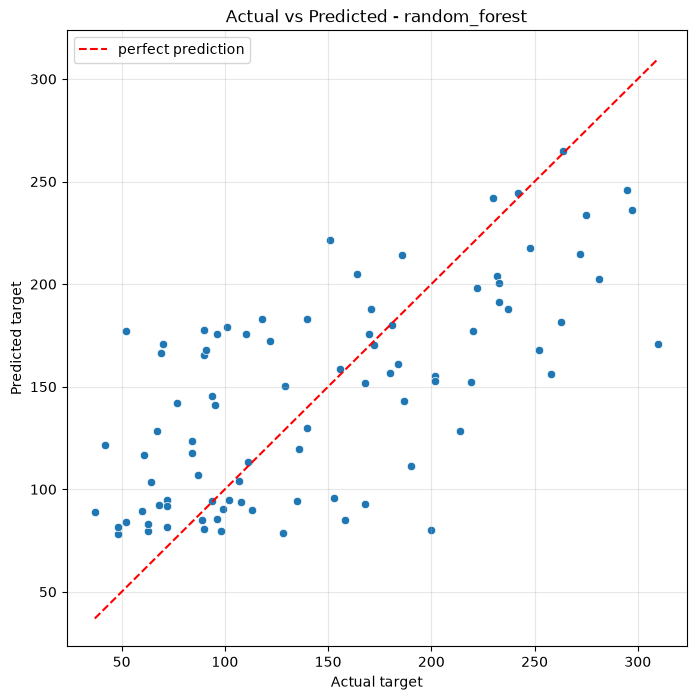

In [13]:
# regression_metric_df는 RMSE 오름차순으로 정렬되어 있다.
# iloc[0]은 가장 낮은 RMSE를 가진 첫 번째 행을 의미한다.
best_regression_name = regression_metric_df.iloc[0]['model']

# best_regression_model: 평가 결과 가장 좋은 모델 객체를 가져온다.
# 앞 셀에서 이미 fit이 끝난 모델이므로 바로 predict()를 사용할 수 있다.
best_regression_model = regression_models[best_regression_name]

# best_regression_pred: 최적 모델이 test 데이터에 대해 예측한 target 값이다.
best_regression_pred = best_regression_model.predict(diabetes_X_test)

plt.figure(figsize=(8, 8))

# x축은 실제값, y축은 예측값이다.
# 점 하나는 test 데이터의 샘플 하나를 의미한다.
sns.scatterplot(x=diabetes_y_test, y=best_regression_pred)

# 빨간 대각선은 예측값이 실제값과 완전히 같은 위치이다.
# 점이 이 선에 가까울수록 예측이 정확하다.
plt.plot(
    [diabetes_y_test.min(), diabetes_y_test.max()],
    [diabetes_y_test.min(), diabetes_y_test.max()],
    color='red',
    linestyle='--',
    label='perfect prediction',
)
plt.xlabel('Actual target')
plt.ylabel('Predicted target')
plt.title(f'Actual vs Predicted - {best_regression_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. 잔차 분포 확인

잔차는 실제값에서 예측값을 뺀 값이다.
잔차가 0 근처에 모이면 예측 오차가 작다는 뜻이고, 한쪽으로 치우치면 과대평가나 과소평가 경향이 있을 수 있다.


,actual,predicted,residual
287,219.0,152.535274,66.464726
211,70.0,170.597984,-100.597984
72,202.0,155.058527,46.941473
321,230.0,242.135074,-12.135074
73,111.0,113.269927,-2.269927


residual mean: -0.149
residual std: 53.7855


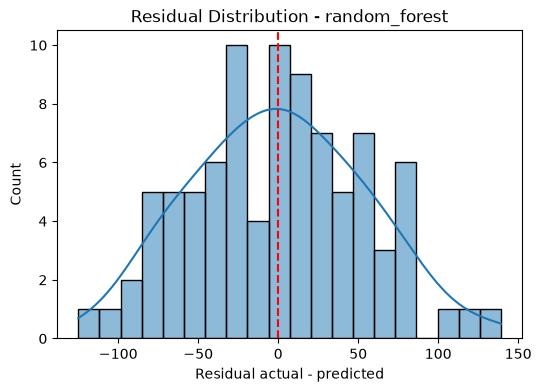

In [14]:
# residuals: 실제값 - 예측값
# 양수이면 모델이 실제값보다 낮게 예측한 것이고, 음수이면 실제값보다 높게 예측한 것이다.
residuals = diabetes_y_test - best_regression_pred

residual_df = pd.DataFrame({
    'actual': diabetes_y_test,
    'predicted': best_regression_pred,
    'residual': residuals,
})

display(residual_df.head())

# residual mean: 잔차 평균
# 0에 가까우면 전체적으로 과대예측/과소예측이 한쪽으로 크게 치우치지 않았다고 볼 수 있다.
print('residual mean:', round(residuals.mean(), 4))

# residual std: 잔차의 흩어진 정도이
# 값이 클수록 샘플별 예측 오차가 넓게 퍼져 있다는 뜻이다.
print('residual std:', round(residuals.std(), 4))

plt.figure(figsize=(6, 4))

sns.histplot(residuals, bins=20, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual actual - predicted')
plt.title(f'Residual Distribution - {best_regression_name}')
plt.show()

## 11. 큰 오차에 민감한 지표 비교

MAE는 오차를 그대로 평균내므로 직관적이다.
MSE와 RMSE는 오차를 제곱하기 때문에 큰 오차가 하나만 있어도 지표가 크게 나빠질 수 있다.


In [15]:
normal_actual = np.array([100, 110, 120, 130, 140])

# normal_pred: 전체적으로 실제값과 비슷하게 예측한 경우
normal_pred = np.array([102, 108, 119, 129, 143])

# outlier_pred: 마지막 예측값 하나가 크게 빗나간 경우
# 나머지 예측은 같지만 마지막 오차가 커져 MAE/RMSE 변화가 발생한다.
outlier_pred = np.array([102, 108, 119, 129, 180])

sensitivity_rows = []

for case_name, pred in [('normal_error', normal_pred), ('one_large_error', outlier_pred)]:
    # 같은 실제값에 대해 예측값만 바꾸어 지표 변화를 비교
    sensitivity_rows.append({
        'case': case_name,
        'MAE': mean_absolute_error(normal_actual, pred),
        'MSE': mean_squared_error(normal_actual, pred),
        'RMSE': root_mean_squared_error(normal_actual, pred),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(4))

# 잘못된 예측(실수)이 치명적으로 작용하는지에 대한 문제는
# RMSE, MSE를 보고 판단할 수 있다

# 평균적인 오차 크기를 직관적으로 설명할 경우에는 MAE를 이용한다.

,case,MAE,MSE,RMSE
0,normal_error,1.8,3.8,1.9494
1,one_large_error,9.2,322.0,17.9444


## 12. 모델 평가 리포트 문장 만들기

평가지표는 숫자만 출력하고 끝내면 수업이나 프로젝트 보고서에서 의미가 부족하다.
어떤 모델을 선택했고, 그 이유가 무엇인지 문장으로 정리해야 한다.


In [16]:
best_row = regression_metric_df.iloc[0]

# 프로젝트에서는 표만 보여주기보다 어떤 지표를 기준으로 어떤 모델을 골랐는지 문장으로 설명해야 한다.
report_sentence = (
    f"가장 낮은 RMSE를 보인 모델은 {best_row['model']}이다. "
    f"이 모델의 MAE는 {best_row['MAE']:.2f}, RMSE는 {best_row['RMSE']:.2f}, "
    f"R2는 {best_row['R2']:.3f}이다. "
    "따라서 평균 오차 크기와 설명력을 함께 고려했을 때 현재 후보 중 가장 적절한 모델로 볼 수 있다."
)

print(report_sentence)

가장 낮은 RMSE를 보인 모델은 random_forest이다. 이 모델의 MAE는 43.27, RMSE는 53.48, R2는 0.460이다. 따라서 평균 오차 크기와 설명력을 함께 고려했을 때 현재 후보 중 가장 적절한 모델로 볼 수 있다.


## 13. 회귀 평가지표 정리

- Residual: 실제값과 예측값의 차이임.
- MAE: 오차 절댓값 평균임. 실제 단위로 설명하기 쉬움.
- MSE: 오차 제곱 평균임. 큰 오차에 민감함.
- RMSE: MSE에 제곱근을 씌운 값임. target과 비슷한 단위로 해석함.
- R2: 평균 예측보다 모델이 얼마나 더 잘 설명하는지 보는 지표임.

회귀 지표는 낮을수록 좋은 지표와 높을수록 좋은 지표가 섞여 있다.
MAE, MSE, RMSE는 낮을수록 좋고, R2는 일반적으로 높을수록 좋다.
